# Final Evaluation

This notebook runs the evaluation script for a pipeline run, loads the generated `evaluation.json`, and creates simple plots for the final submission metrics.

For the final validation report, use a run created with:

```bash
python scripts/run_pipeline.py --skip-dedup
```

Using `--skip-dedup` gives every labelled validation crop a direct decision.

## 1. Setup

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "artifacts" / "runs").exists() and (PROJECT_ROOT.parent / "artifacts" / "runs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RUNS_DIR = PROJECT_ROOT / "artifacts" / "runs"
PLOTS_DIRNAME = "final_evaluation_plots"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130
pd.set_option("display.max_colwidth", 120)

## 2. Select Run And Execute Evaluation

Set `RUN_ID` if you want a specific run. Leave it as `None` to evaluate the latest run folder.

In [2]:
RUN_ID: str | None = None


def latest_run_dir(runs_dir: Path) -> Path:
    candidates = [p for p in runs_dir.iterdir() if p.is_dir()]
    if not candidates:
        raise FileNotFoundError(f"No run folders found in {runs_dir}")
    return max(candidates, key=lambda p: p.stat().st_mtime)


run_dir = RUNS_DIR / RUN_ID if RUN_ID else latest_run_dir(RUNS_DIR)
print(f"Evaluating run: {run_dir.name}")

cmd = [sys.executable, "scripts/evaluate.py", "--run-folder", str(run_dir)]
completed = subprocess.run(
    cmd,
    cwd=PROJECT_ROOT,
    text=True,
    capture_output=True,
    encoding="utf-8",
    errors="replace",
)

print(completed.stdout)
if completed.stderr:
    print(completed.stderr)

if completed.returncode != 0:
    raise RuntimeError(f"Evaluation failed with exit code {completed.returncode}")

Evaluating run: 2026-05-12_204240
20:45:37 | INFO     | src.logger.custom_logger:configure_logger:59 | Logger configured — log file: C:\Users\rsurs\OneDrive\Documents\cynapse-ai-assignment\logs\2026-05-12\20-45-37.log
20:45:40 | INFO     | src.logger.custom_logger:configure_logger:59 | Logger configured — log file: C:\Users\rsurs\OneDrive\Documents\cynapse-ai-assignment\logs\2026-05-12\20-45-40.log
20:45:40 | INFO     | src.data.labels:load_validation_csv:47 | Loaded 213 from validation.csv
20:45:40 | INFO     | src.pipeline.evaluation_pipeline:evaluate_run:158 | Evaluating: 1001 decisions vs. 213 labels
20:45:40 | WARNING  | src.pipeline.evaluation_pipeline:evaluate_run:178 | 27 labeled crops have no matching decision (likely removed by dedup or absent from data_dir). First few: ['crop (1100)', 'crop (160)', 'crop (169)', 'crop (211)', 'crop (243)']

───────────────────────────── Overall Performance ─────────────────────────────
 Crops evaluated                         186 
 Labels wi

## 3. Load Evaluation Results

In [3]:
evaluation_path = run_dir / "evaluation.json"
with evaluation_path.open("r", encoding="utf-8") as f:
    evaluation = json.load(f)

overall = evaluation["overall"]
counts = overall["counts"]
violations_df = pd.DataFrame(evaluation["violations"])

summary_df = pd.DataFrame(
    [
        {"metric": "Crops evaluated", "value": evaluation["n_evaluated"]},
        {"metric": "Labels without decisions", "value": evaluation["n_unmatched_labels"]},
        {"metric": "Accuracy", "value": overall["accuracy"]},
        {"metric": "Precision keep", "value": overall["precision_keep"]},
        {"metric": "Recall keep", "value": overall["recall_keep"]},
        {"metric": "F1 keep", "value": overall["f1_keep"]},
        {"metric": "Coverage", "value": overall["coverage"]},
    ]
)

summary_df

,metric,value
0,Crops evaluated,186.0000
1,Labels without decisions,27.0000
2,Accuracy,0.8978
3,Precision keep,0.6522
4,Recall keep,0.5769
5,F1 keep,0.6122
6,Coverage,0.9500


In [4]:
display_columns = [
    "violation",
    "n_labeled",
    "n_rejected",
    "coverage",
    "coverage_at_expected_stage",
]

violations_display = violations_df[display_columns].copy()
violations_display["coverage"] = violations_display["coverage"].map(lambda x: f"{x:.2%}")
violations_display["coverage_at_expected_stage"] = violations_display[
    "coverage_at_expected_stage"
].map(lambda x: f"{x:.2%}")

violations_display

,violation,n_labeled,n_rejected,coverage,coverage_at_expected_stage
0,no_person,35,35,100.00%,62.86%
1,blurry,24,24,100.00%,54.17%
2,face_hidden,22,22,100.00%,59.09%
3,advertisement,28,27,96.43%,0.00%
4,not_full_body,43,38,88.37%,41.86%
5,minor,8,6,75.00%,62.50%


## 4. Create Plots

In [5]:
plots_dir = run_dir / PLOTS_DIRNAME
plots_dir.mkdir(parents=True, exist_ok=True)
print(f"Saving plots to: {plots_dir}")

Saving plots to: C:\Users\rsurs\OneDrive\Documents\cynapse-ai-assignment\artifacts\runs\2026-05-12_204240\final_evaluation_plots


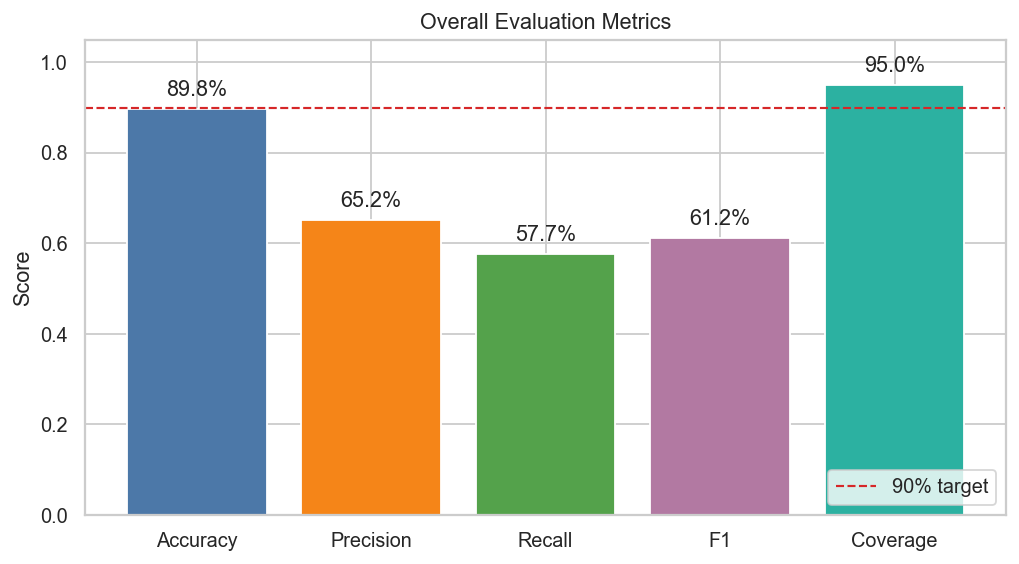

In [6]:
metric_order = ["accuracy", "precision_keep", "recall_keep", "f1_keep", "coverage"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1", "Coverage"]
metric_values = [overall[m] for m in metric_order]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(metric_labels, metric_values, color=["#4C78A8", "#F58518", "#54A24B", "#B279A2", "#2CB1A1"])
ax.axhline(0.90, color="#D62728", linestyle="--", linewidth=1.2, label="90% target")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Overall Evaluation Metrics")
ax.legend(loc="lower right")

for bar, value in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.1%}", ha="center", va="bottom")

fig.tight_layout()
fig.savefig(plots_dir / "overall_metrics.png", bbox_inches="tight")
plt.show()

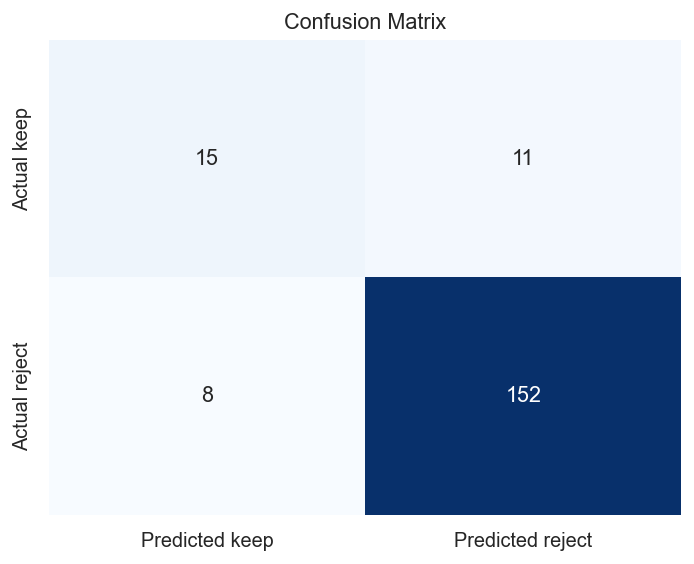

In [7]:
confusion = pd.DataFrame(
    [[counts["tp"], counts["fn"]], [counts["fp"], counts["tn"]]],
    index=["Actual keep", "Actual reject"],
    columns=["Predicted keep", "Predicted reject"],
)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Confusion Matrix")
fig.tight_layout()
fig.savefig(plots_dir / "confusion_matrix.png", bbox_inches="tight")
plt.show()

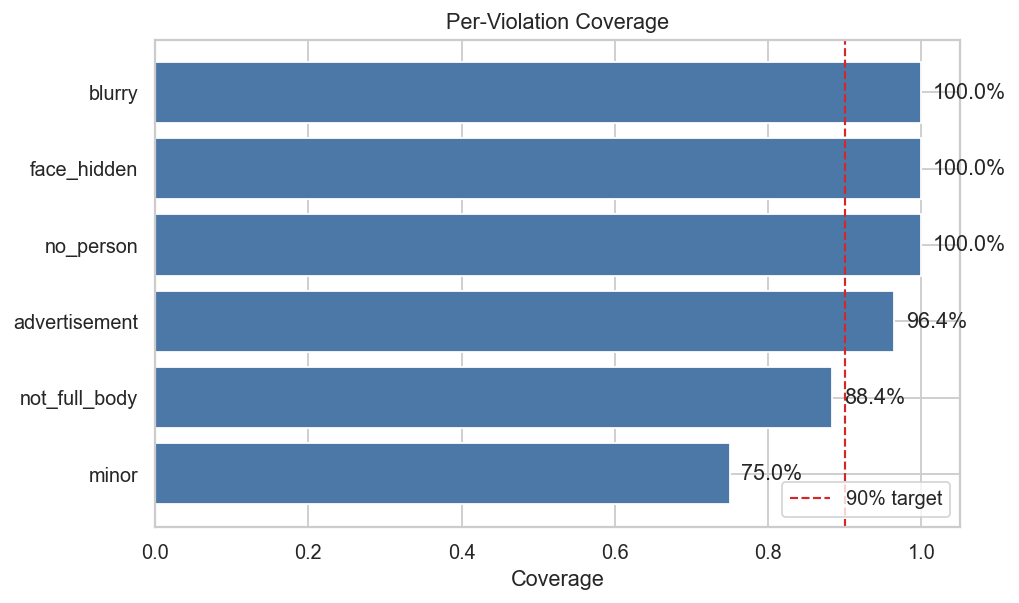

In [8]:
coverage_plot_df = violations_df.sort_values("coverage", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.barh(coverage_plot_df["violation"], coverage_plot_df["coverage"], color="#4C78A8")
ax.axvline(0.90, color="#D62728", linestyle="--", linewidth=1.2, label="90% target")
ax.set_xlim(0, 1.05)
ax.set_xlabel("Coverage")
ax.set_title("Per-Violation Coverage")
ax.legend(loc="lower right")

for bar, value in zip(bars, coverage_plot_df["coverage"]):
    ax.text(value + 0.015, bar.get_y() + bar.get_height() / 2, f"{value:.1%}", va="center")

fig.tight_layout()
fig.savefig(plots_dir / "per_violation_coverage.png", bbox_inches="tight")
plt.show()

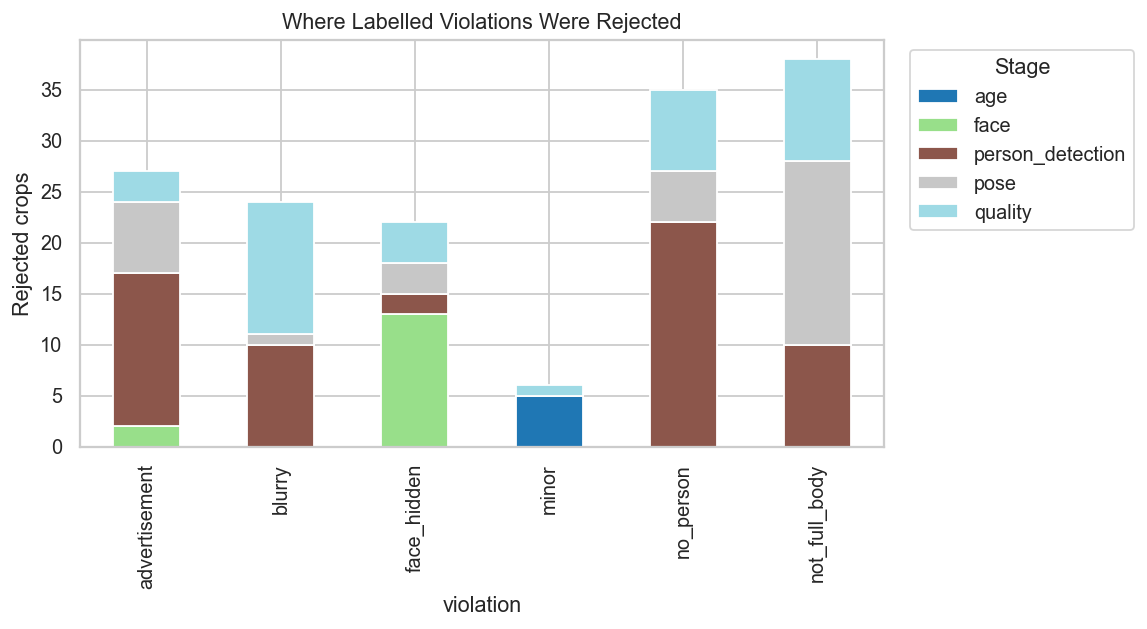

In [9]:
stage_rows = []
for record in evaluation["violations"]:
    for stage, count in record["stage_breakdown"].items():
        stage_rows.append({"violation": record["violation"], "stage": stage, "count": count})

stage_df = pd.DataFrame(stage_rows)
stage_pivot = stage_df.pivot_table(
    index="violation",
    columns="stage",
    values="count",
    aggfunc="sum",
    fill_value=0,
)

fig, ax = plt.subplots(figsize=(9, 5))
stage_pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_ylabel("Rejected crops")
ax.set_title("Where Labelled Violations Were Rejected")
ax.legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(plots_dir / "violation_stage_breakdown.png", bbox_inches="tight")
plt.show()

## 5. Submission Notes

In [10]:
coverage = overall["coverage"]
unmatched = evaluation["n_unmatched_labels"]

print(f"Final run: {run_dir.name}")
print(f"Coverage: {coverage:.2%}")
print(f"Labels without decisions: {unmatched}")
print("Passes >90% coverage target:", coverage > 0.90)

if unmatched != 0:
    print("Warning: some labelled crops did not receive decisions.")

minor_row = violations_df.loc[violations_df["violation"] == "minor"]
if not minor_row.empty:
    n_minor = int(minor_row.iloc[0]["n_labeled"])
    print(f"Minor validation examples: {n_minor} (limited sample size)")

Final run: 2026-05-12_204240
Coverage: 95.00%
Labels without decisions: 27
Passes >90% coverage target: True
Minor validation examples: 8 (limited sample size)
